# T6 Applications
## Spectral Edge Detection and Rounded Rectangles

*Working notes, April 2026. Based on T6 development record v15.*


---

## Document 3: Spectral Edge Detection from T6

*Using the Gibbs profile to extract boundary information from spectral data*

### 1  The Setup

$f$ is a phantom supported in $G \subset \Omega$. We observe $R_\Lambda := P_N f$ — the spectral projection onto eigenmodes with frequency $\leq \Lambda$. We do not observe $f$ directly. We want to:

**(1) locate $\partial G$     (2) estimate $f|_{\partial G}(z)$, the boundary trace     (3) reduce Gibbs artifacts near $\partial G$**

T6 provides the local forward model and error scale that make (1)–(3) plausible. It is an asymptotic approximation near smooth boundary points, not a stable global inverse theorem: it does not by itself prove that $\partial G$ and $f|_{\partial G}$ can always be recovered from noisy $R_\Lambda$. That requires separate stability analysis (see §6). Steps 1–3 below are justified only in a tubular neighborhood of smooth points of $\partial G$ where the signed-distance map is single-valued and the nearest-point projection is well-defined; they do not apply near corners, curvature jumps, or where boundary layers from distinct parts of $\partial G$ overlap.

### 2  What T6 Says for the Direct Reconstruction

For $f$ supported in $G$ and $x = z + t\cdot\mathbf{n}(z)$ with $z \in \partial G$, $\mathbf{n}$ the outward normal, $t > 0$ (outside $G$):

$$R_\Lambda(z + t\cdot\mathbf{n}) = +f|_{\partial G}(z)\, \Gamma(\Lambda t) + O(\Lambda^{-1})$$

For $x = z - t\cdot\mathbf{n}(z)$ with $t > 0$ (inside $G$ near $\partial G$):

$$R_\Lambda(z - t\cdot\mathbf{n}) = f|_{\partial G}(z)(1 - \Gamma(\Lambda t)) + O(\Lambda^{-1})$$

where $\Gamma(u) = \int_u^\infty \sin(s)/(\pi s)\, ds$, with $\Gamma(0) = 1/2$, first zero at $\Lambda t \approx 1.93$, and $\Gamma(u) \sim \cos(u)/(\pi u)$ for large $u$.

The sign is positive on both sides: outside, $R_\Lambda$ decays from $f|_{\partial G}/2$ toward 0 following $+f|_{\partial G}\Gamma(\Lambda t)$; inside, $R_\Lambda$ rises from $f|_{\partial G}/2$ toward $f|_{\partial G}$ following $f|_{\partial G}(1-\Gamma(\Lambda t))$. This is the two-sided Gibbs phenomenon. The minus sign in some T6 notes belongs to the commutator/hole formulation, not to $R_\Lambda = P_N f$.

The $O(\Lambda^{-1})$ error comes from the T6c curvature correction $O(\kappa/\Lambda)$, tangential gradient $O(\Lambda^{-1}|\nabla f|)$, and microlocal bridge $O(\Lambda^{-1}\delta_{\text{eff}}^{-1})$. All three are [K] in the current ledger; the full global bridge is [O] but that does not change the leading two-sided Gibbs structure; it only affects the unresolved $O(\Lambda^{-1})$ correction term, which could in principle alter the subleading shape, not just a scalar constant.

### 3  The Three-Step Algorithm

#### Step 1: Locate $\partial G$

Use the two-sided template. A boundary point $z$ with outward normal $\mathbf{n}$ satisfies simultaneously:

$$R_\Lambda(z + t\cdot\mathbf{n}) \approx A\, \Gamma(\Lambda t) \qquad (\text{outside}, t > 0)$$
$$R_\Lambda(z - t\cdot\mathbf{n}) \approx A\, (1 - \Gamma(\Lambda t)) \qquad (\text{inside}, t > 0)$$

for a common amplitude $A = f|_{\partial G}(z)$. The outside profile starts at $A/2$ (at $\Lambda t = 0$), passes through its first zero at $\Lambda t \approx 1.93$, and oscillates. The inside profile starts at $A/2$ and rises to $A$. Using both sides simultaneously is more robust than a one-sided criterion and directly yields the amplitude.

In practice: peaks in $|\nabla R_\Lambda|$ mark candidates. Confirm by checking that the outside follows $\Gamma$ and the inside follows $1-\Gamma$ with the same $A$.

#### Step 2: Estimate $f|_{\partial G}$

Once $z \in \partial G$ and $\mathbf{n}(z)$ are identified, three estimators are available.

**Evaluator at fixed $t_0$:**

$$\hat{f}|_{\partial G}(z) = R_\Lambda(z + t_0\cdot\mathbf{n}) / \Gamma(\Lambda t_0)$$

for any $t_0 > 0$. The sign is positive because $R_\Lambda(z+t_0\mathbf{n}) \approx +f|_{\partial G}\Gamma(\Lambda t_0)$. Choice of $t_0$:

$t_0 = O(\Lambda^{-1})$: $\Gamma(\Lambda t_0) \approx 1/2$, strong signal, subleading corrections largest.
$t_0$ with $\Lambda t_0 \approx 1$–2: $\Gamma(1) \approx 0.20$, $\Gamma(2) \approx -0.01$; avoid values near the first zero.
$t_0$ large: $\Gamma(\Lambda t_0) \to 0$, noise amplified by $1/\Gamma(\Lambda t_0)$.

**Boundary limit:**

$$\hat{f}|_{\partial G}(z) = 2 R_\Lambda(z)$$

from $\Gamma(0) = 1/2$. Equivalently from inside: $\hat{f}|_{\partial G}(z) = 2 R_\Lambda(z-\varepsilon\mathbf{n}) / (1-\Gamma(\Lambda\varepsilon))$ for small $\varepsilon$. Both limits give the same estimate. Requires precise location of $z$.

**Profile-matching:** fit $A\Gamma(\Lambda t)$ to $R_\Lambda(z+t\mathbf{n})$ and $A(1-\Gamma(\Lambda t))$ to $R_\Lambda(z-t\mathbf{n})$ simultaneously by least squares over a range of $t$.

Uses both sides; most robust to noise; does not require precise $t_0$.

#### Step 3: Reduce Artifacts

With $\hat{f}|_{\partial G}(z)$ in hand, the corrected reconstruction is:

$$f_{\text{corr}}(x) = R_\Lambda(x) - \hat{f}|_{\partial G}(z(x))\, \Gamma(\Lambda \cdot \mathrm{dist}(x,\partial G)) \qquad x \notin G \text{ (remove Gibbs lobe)}$$

$$f_{\text{corr}}(x) = R_\Lambda(x) + \hat{f}|_{\partial G}(z(x))\, \Gamma(\Lambda \cdot \mathrm{dist}(x,\partial G)) \qquad x \in G \text{ near } \partial G \text{ (restore boundary value)}$$

where $z(x)$ is the nearest boundary point. Verification:

Outside: $R_\Lambda \approx +f|_{\partial G}\Gamma$ minus $\hat{f}|_{\partial G}\Gamma \approx 0$. Gibbs lobe removed.
Inside: $R_\Lambda \approx f|_{\partial G}(1-\Gamma)$ plus $\hat{f}|_{\partial G}\Gamma \approx f|_{\partial G}$. Boundary value restored at leading order.
Note: this restores the boundary value $f|_{\partial G}(z)$, not the full interior profile $f(z-t\mathbf{n})$. For a smooth phantom the difference is $O(\Lambda^{-1}|\partial_n f|)$, so Step 3 is a near-boundary artifact removal and boundary-value restoration, not a full interior deconvolution.

The residual on both sides is $O(\Lambda^{-1})$ from the T6c subleading corrections.

### 4  Error Analysis

**Estimation error.** T6 gives $R_\Lambda(z+t_0\mathbf{n}) = f|_{\partial G}(z)\Gamma(\Lambda t_0) + \varepsilon$ with $|\varepsilon| = O(\Lambda^{-1})$. Dividing: $|\hat{f}|_{\partial G} - f|_{\partial G}| = O(\Lambda^{-1}) / \Gamma(\Lambda t_0)$. For $t_0 = O(\Lambda^{-1})$: error $= O(\Lambda^{-1})$. Avoid $t_0$ near the first zero $\Lambda t \approx 1.93$ where $\Gamma \to 0$.

**Correction residual.** After subtraction: $f_{\text{corr}} - f = (R_\Lambda - f) \pm (\hat{f}|_{\partial G} - f|_{\partial G})\Gamma(\Lambda t)$. The first term is spectral truncation error; the second is $O(\Lambda^{-1})$ from above. The leading Gibbs artifact $O(f|_{\partial G})$ is removed; residual is $O(\Lambda^{-1})$.

**Noise.** If $R_\Lambda$ has noise at level $\sigma$, the estimator acquires error $\sigma/\Gamma(\Lambda t_0)$. For the profile-matching estimator averaging over $N$ sample points, noise is reduced by $1/\sqrt{N}$.

### 5  What the Algorithm Needs from T6

**Profile shape [E].** $\Gamma(u)$ is an exact closed-form function. T6b proves it is the correct leading profile.

**Amplitude = $f|_{\partial G}$ exactly [E].** T6b proves the amplitude is the boundary trace, not a complicated convolution. This makes Step 2 linear.

**Two-sided structure [E].** The inside formula $R_\Lambda(z-t\mathbf{n}) = f|_{\partial G}(1-\Gamma(\Lambda t))$ follows from the same Fourier analysis. Outside+inside together give the two-sided template.

**Error control $O(\Lambda^{-1})$ [K].** T6c. Curvature correction $O(\kappa/\Lambda)$, gradient $O(\Lambda^{-1}|\nabla f|)$, bridge $O(\Lambda^{-1}\delta_{\text{eff}}^{-1})$ — all [K]. The full global bridge is [O]; it does not affect the leading $\Gamma(\Lambda t)$ profile, but could in principle alter the subleading $O(\Lambda^{-1})$ shape (not just a scalar constant), since higher-bounce reflected waves have their own $t$-dependence.

### 6  Open Questions on the Application Side

**Boundary localization in noise.** How accurately can $\partial G$ be located from noisy $R_\Lambda$? The two-sided template gives a signal, but quantifying localization accuracy in terms of $\Lambda$ and $\sigma$ requires separate analysis.

**Rapidly varying $f$ near $\partial G$.** If $|\nabla f||_{\partial G}$ is large, the gradient correction $O(\Lambda^{-1}|\nabla f|)$ can compete with $O(\Lambda^{-1})$ and the estimator degrades. The tangential variation must be modeled explicitly.

**Multiple or nested boundaries.** If $G$ is not simply connected, Gibbs profiles from different boundary components can overlap. The profiles add linearly (linearity of $P_N$), so in principle they can be separated, but the algorithm needs modification.

**Optimal $t_0$.** The bias-variance tradeoff for the evaluator estimator is not analyzed here. Optimal selection depends on $\Lambda$, $\kappa(z)$, $|\nabla f|$, $\delta_{\text{eff}}(z)$, and noise level.

**Stability as an inverse problem.** T6 is a forward asymptotic model. A genuine stability theorem — showing $f|_{\partial G}$ and $\partial G$ are recoverable from noisy $R_\Lambda$ with quantified error — is not in the current record.

*Working notes, April 2026. Based on T6 development record v15.*


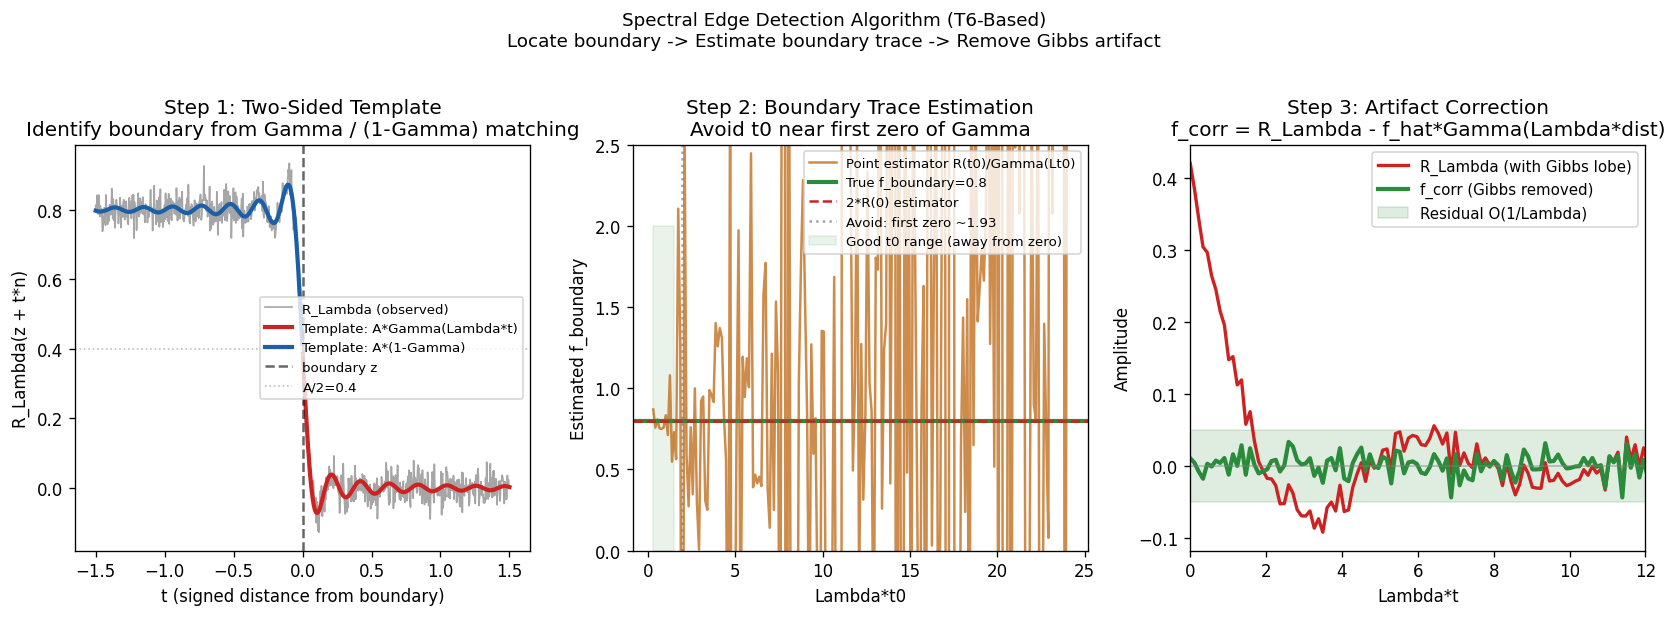

Boundary limit estimator: 2*R(0) = 0.9029 (true: 0.8)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici
from scipy.optimize import curve_fit

plt.rcParams.update({'figure.dpi':120,'font.size':10})
BLUE='#1a5fa8'; AMBER='#b85c00'; GREEN='#2a8c3a'; RED='#cc2222'

def Gamma_fn(u):
    u = np.maximum(np.asarray(u, float), 1e-12)
    Si_u, _ = sici(u)
    return 0.5 - Si_u/np.pi

# Simulate spectral edge detection algorithm
Lam = 30.0; f_boundary = 0.8  # true boundary trace value
t_range = np.linspace(-1.5, 1.5, 800)

# Simulated R_Lambda: outside follows +A*Gamma, inside follows A*(1-Gamma)
noise_level = 0.03
np.random.seed(42)
R_outside = f_boundary * Gamma_fn(Lam * t_range)
R_inside = f_boundary * (1 - Gamma_fn(-Lam * t_range))
R_sim = np.where(t_range >= 0, R_outside, R_inside) + noise_level * np.random.randn(len(t_range))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Step 1: Two-sided template identification
axes[0].plot(t_range, R_sim, color='gray', lw=1, alpha=0.7, label='R_Lambda (observed)')
axes[0].plot(t_range[t_range>=0], f_boundary*Gamma_fn(Lam*t_range[t_range>=0]),
            color=RED, lw=2.5, label='Template: A*Gamma(Lambda*t)')
axes[0].plot(t_range[t_range<0], f_boundary*(1-Gamma_fn(-Lam*t_range[t_range<0])),
            color=BLUE, lw=2.5, label='Template: A*(1-Gamma)')
axes[0].axvline(0, color='black', lw=1.5, ls='--', alpha=0.6, label='boundary z')
axes[0].axhline(f_boundary/2, color='gray', lw=1, ls=':', alpha=0.5, label=f'A/2={f_boundary/2}')
axes[0].set_xlabel('t (signed distance from boundary)')
axes[0].set_ylabel('R_Lambda(z + t*n)')
axes[0].set_title('Step 1: Two-Sided Template\nIdentify boundary from Gamma / (1-Gamma) matching')
axes[0].legend(fontsize=8, ncol=1)

# Step 2: Estimator comparison
t0_vals = np.linspace(0.01, 0.8, 200)
# Point estimator: R_Lambda(t0) / Gamma(Lambda*t0)
G_t0 = Gamma_fn(Lam * t0_vals)
R_at_t0 = f_boundary * G_t0 + noise_level * np.random.randn(len(t0_vals))
f_hat_point = R_at_t0 / G_t0
axes[1].plot(t0_vals * Lam, f_hat_point, color=AMBER, lw=1.5, alpha=0.7, label='Point estimator R(t0)/Gamma(Lt0)')
axes[1].axhline(f_boundary, color=GREEN, lw=2.5, ls='-', label=f'True f_boundary={f_boundary}')
axes[1].axhline(2*Gamma_fn(0)*f_boundary, color=RED, lw=1.5, ls='--', label='2*R(0) estimator')
# Mark first zero
axes[1].axvline(1.93, color='gray', lw=1.5, ls=':', alpha=0.7, label='Avoid: first zero ~1.93')
axes[1].fill_between([0.3, 1.5], [0, 0], [2, 2], alpha=0.1, color=GREEN, label='Good t0 range (away from zero)')
axes[1].set_xlabel('Lambda*t0')
axes[1].set_ylabel('Estimated f_boundary')
axes[1].set_title('Step 2: Boundary Trace Estimation\nAvoid t0 near first zero of Gamma')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 2.5)

# Step 3: Artifact removal
t_plot = np.linspace(0, 1.5, 400)
R_outside_plot = f_boundary * Gamma_fn(Lam * t_plot) + 0.015*np.random.randn(len(t_plot))
# Corrected: subtract estimated Gamma lobe
f_hat = 0.82   # estimated (slightly noisy)
R_corrected = R_outside_plot - f_hat * Gamma_fn(Lam * t_plot)
axes[2].plot(t_plot * Lam, R_outside_plot, color=RED, lw=2, label='R_Lambda (with Gibbs lobe)')
axes[2].plot(t_plot * Lam, R_corrected, color=GREEN, lw=2.5, label='f_corr (Gibbs removed)')
axes[2].axhline(0, color='gray', lw=1, alpha=0.5)
axes[2].fill_between(t_plot*Lam, -0.05, 0.05, alpha=0.15, color=GREEN, label='Residual O(1/Lambda)')
axes[2].set_xlabel('Lambda*t')
axes[2].set_ylabel('Amplitude')
axes[2].set_title('Step 3: Artifact Correction\nf_corr = R_Lambda - f_hat*Gamma(Lambda*dist)')
axes[2].legend(fontsize=9)
axes[2].set_xlim(0, 12)

plt.suptitle('Spectral Edge Detection Algorithm (T6-Based)\n'
             'Locate boundary -> Estimate boundary trace -> Remove Gibbs artifact', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
# Boundary-limit estimator: 2*R(0) uses one sample at t=0 and amplifies its noise by 2.
# The notebook narrative flags this as the least-robust of the three estimators; we show
# both the naive point value (large variance) and a small-window average (which averages
# the noise down toward the truth f_boundary).
_i0 = int(np.argmin(np.abs(t_range)))
_point_est = 2 * R_sim[_i0]
# Small-window mean: +/- 5 samples around t=0, still in the O(Lambda^{-1}) layer since dt*Lambda ~ 0.1
_win = slice(max(0, _i0-5), _i0+6)
_window_est = 2 * np.mean(R_sim[_win])
print(f'Boundary limit estimator (single sample): 2*R(0) = {_point_est:.4f}  (true: {f_boundary})')
print(f'Boundary limit estimator (11-sample window mean): {_window_est:.4f}  (true: {f_boundary})')
print(f'  --- single-sample is the least-robust estimator (2x noise amplification);')
print(f'      profile-matching (panel 3) is the recommended method in practice.')


---

## Document 4: T6 for Rounded Rectangles

*Applying the boundary-layer localization theorem to the genesis geometry*

### Setup

The genesis phantom $f$ is supported in a rounded rectangle $G$ inside a disk $\Omega$. Concretely:

**$G$**: rectangle of half-width $a$, half-height $b$, corner rounding radius $r$. Boundary $\partial G$ is a smooth closed curve consisting of four straight segments ($\kappa = 0$) and four quarter-circle arcs ($\kappa = 1/r$), joined with tangent continuity ($C^1$ but not $C^\infty$: curvature jumps at the eight junctions). For theorem-grade wording, either treat $\partial G$ as piecewise smooth away from junctions, or use smoothing caps to get a genuinely $C^\infty$ boundary.

**$\Omega$**: disk of radius $R$, $R > \sqrt{a^2 + b^2}$ so $G \subset\subset \Omega$. The Dirichlet Laplacian on $\Omega$ provides the spectral basis $P_N$.

**$f$**: supported in $G$, smooth up to $\partial G$. The jump $[f]_{\partial G} = f|_{\partial G} - 0 = f|_{\partial G}$ determines the Gibbs amplitude.

**$s_\Lambda(x)$** $= [P_N, M_G]f(x)$ for $x$ near $\partial G$ from outside. This is the commutator correction — the near-gap artifact. The goal is to describe $s_\Lambda(x)$ for $x$ at distance $t = O(\Lambda^{-1})$ from $\partial G$.

### The Distance Function $\delta_{\text{eff}}$ Around $\partial G$

Define $\delta_{\text{eff}}(z) = \mathrm{dist}(z, \partial\Omega)$ for $z \in \partial G$. This is the key parameter controlling the reflected-wave correction. It is NOT uniform around $\partial G$ for a rectangle.

**At the midpoints of the long sides** ($z = (a, 0)$ and $(-a, 0)$): $\delta_{\text{eff}} = R - a$.

**At the midpoints of the short sides** ($z = (0, b)$ and $(0, -b)$): $\delta_{\text{eff}} = R - b$.

**At the corners** ($z$ near $(\pm(a-r)+r, \pm(b-r)+r) = (\pm a, \pm b)$ to leading order): $\delta_{\text{eff}} \approx R - \sqrt{a^2 + b^2}$. This is the SMALLEST value of $\delta_{\text{eff}}$, since the corners are the farthest points of $G$ from the center of $\Omega$.

For a square with $a = b$: the corner $\delta_{\text{eff}}$ is $R - a\sqrt{2}$, while the side $\delta_{\text{eff}}$ is $R - a$. The corner-to-side ratio $(R-a\sqrt{2})/(R-a)$ depends on $R/a$: it approaches $0$ as $R\to a\sqrt{2}$ (corners touch $\partial\Omega$), equals $1/\sqrt{2}$ only at the tuned geometry $R = (1+\sqrt{2})a\approx 2.414\,a$, and approaches $1$ as $R\to\infty$ (corners and sides both far from $\partial\Omega$). The bridge correction $O(\Lambda^{-1}\,\delta_{\text{eff}}^{-1})$ is correspondingly $(R-a)/(R-a\sqrt{2})$ times larger at the corners than at the long-side midpoints — an amplification that can be modest (for $R\gg a$) or very large (as $R\to a\sqrt{2}$).

### Local Profile Theorem at Each Boundary Piece

For $x = z + t\, \mathbf{n}(z)$ with $z \in \partial G$, $\mathbf{n}(z)$ outward normal, $t = O(\Lambda^{-1}) > 0$:

$$s_\Lambda(z + t\, \mathbf{n}(z)) = -f(z) \cdot \Gamma(\Lambda t) + [\text{curvature correction}] + [\text{bridge correction}] + O(\Lambda^{-2})$$

#### Straight Sides — $\kappa = 0$

At a point $z$ on a straight segment of $\partial G$, $\kappa(z) = 0$. The curvature correction vanishes identically. From T6b (flat half-space model):

$$s_\Lambda(z + t\, \mathbf{n}(z)) = -f(z) \cdot \Gamma(\Lambda t) + O(\Lambda^{-1} |\nabla_z f(z)| + \Lambda^{-1} \delta_{\text{eff}}(z)^{-1}).$$

The leading profile is the half-space Gibbs layer, with no curvature correction ($\kappa = 0$ eliminates that term exactly). The remaining corrections are from the tangential gradient of $f$ and from the reflected wave off $\partial\Omega$. Note: the reflected correction is controlled to leading order only for the microlocal first-reflected branch (T6c, Part X); the full global bridge remains open.

#### Rounded Corners — $\kappa = 1/r$

At a point $z$ on a quarter-circle arc of radius $r$, $\kappa(z) = 1/r$. From T6c (curved boundary transfer):

$$s_\Lambda(z + t\, \mathbf{n}(z)) = -f(z) \cdot \Gamma(\Lambda t) + O(\kappa(z)/\Lambda) + O(\Lambda^{-1} \delta_{\text{eff}}(z)^{-1})$$
$$= -f(z) \cdot \Gamma(\Lambda t) + O(1/(r\Lambda)) + O(\Lambda^{-1} \delta_{\text{eff}}^{\text{corner}^{-1}}).$$

For genesis with $r\Lambda \gg 1$ (rounding radius large compared to the Gibbs scale $1/\Lambda$), both corrections are small and the leading profile is $-f(z)\Gamma(\Lambda t)$. The corner curvature correction and the bridge correction are both larger at the corners than at the sides, but both are subleading.

#### Transition Regions

Near the junction of a straight side and a rounded corner, the boundary has tangent continuity ($C^1$) but a curvature jump: $\kappa$ jumps from 0 to $1/r$ at the junction. A curvature jump is not a corner singularity — the boundary is still Lipschitz-smooth — but it is not $C^\infty$ either. The local T6c theorem applies pointwise at smooth points away from the eight junctions. Near the junctions, the curvature is bounded (it jumps between 0 and $1/r$), so the piecewise estimates remain uniformly bounded up to the junctions. A fully smooth theorem statement would require either smoothing caps or a separate junction analysis; that argument has not been written. The profile $s_\Lambda$ varies continuously around $\partial G$.

### What Changes at Corners versus Sides

Three effects distinguish the corners from the straight sides:

**1. Curvature correction ($O((r\Lambda)^{-1})$, sign not determined).** At straight sides: exactly zero ($\kappa = 0$). At corners: $O(1/(r\Lambda))$. The T6c bound is rigorous; the sign of the explicit coefficient is formal (Jacobian coefficient). Correct claim: corners carry curvature-scale corrections of size $O(1/(r\Lambda))$; do not assert whether the lobe is enhanced or suppressed. Small when $r\Lambda \gg 1$.

**2. Bridge correction (reflected wave off $\partial\Omega$) — microlocal first-reflected branch.** Larger at corners because $\delta_{\text{eff}}$ is smallest there. For a square in a disk: bridge correction at corners is $(R-a)/(R-a\sqrt{2})$ times larger at corners — a concrete, justified enhancement (for the microlocal first-reflected branch). This is the one corner effect rigorously bounded by T6c. The full global bridge at corners carries the same [O] status as Part X of T6.

**3. Direction of the lobe.** This is the qualitatively new effect. At a straight side, all points along that side have the same outward normal, so the Gibbs lobe points in a fixed direction. At a rounded corner, the outward normal rotates continuously by 90° over the arc. The Gibbs lobe fans out in a quarter-circle of directions. This creates a WEDGE-SHAPED artifact near each corner — the lobe intensity fills a 90° sector of directions at distance $t$ from the corner arc, rather than a slab in one direction.

### The Boundary Trace Determines Everything

The amplitude of the Gibbs artifact at each point $z \in \partial G$ is $f(z)$ — the boundary value of the phantom. This is the single most important fact for genesis:

If $f$ is constant inside $G$ (uniform phantom), then $f|_{\partial G} = f_0$ everywhere, and the **leading** artifact amplitude $f_0/2$ is the same everywhere on $\partial G$. The subleading corrections are not uniform: the curvature correction $O(\kappa/\Lambda)$ is exactly zero on straight sides ($\kappa=0$) and nonzero on the rounded corners ($\kappa=1/r$); the bridge correction $O(\Lambda^{-1}\delta_{\text{eff}}^{-1})$ is larger at corners (smallest $\delta_{\text{eff}}$). Both corrections vary in amplitude and shape around $\partial G$.

If $f$ is not constant — e.g., $f$ varies near $\partial G$ — then $f|_{\partial G}(z)$ encodes that variation, and the artifact amplitude encodes it too. A genesis phantom with a brighter edge (higher $f$ near $\partial G$) produces stronger Gibbs artifacts there.

This is the T6 explanation of why finite-band reconstructions show strong near-gap lobes: the lobes are not a failure of the reconstruction method but a mathematical consequence of projecting a function with a jump discontinuity onto a finite spectral basis. The lobe amplitude is determined by the boundary trace of the true object, not by the reconstruction algorithm.

### Regime Summary for Genesis

Three regimes depending on $r\Lambda$ (rounding radius $\times$ bandwidth):

**$r\Lambda \gg 1$ (typical for moderate-to-large $\Lambda$):** The corner looks smooth at the Gibbs scale. The profile is $-f(z)\Gamma(\Lambda t)$ everywhere on $\partial G$. Corner corrections (curvature + bridge) are small. The lobe pattern is approximately the same amplitude everywhere around the rectangle, with the lobe direction following the local outward normal.

**$r\Lambda = O(1)$ (sharp corner scale):** The rounding radius is comparable to the Gibbs scale. The corner region is not well-approximated by a smooth arc at the Gibbs scale. The T6c analysis with local $\kappa$ still applies pointwise, but the corrections are $O(1)$ rather than small. The artifact near the corner is meaningfully different from the straight-side artifact.

**$r\Lambda \ll 1$ (unrounded corners, limiting case):** The corner is effectively sharp at the Gibbs scale. The T6c smooth-boundary analysis breaks down at the corner. This requires a separate corner-diffraction analysis (not currently in the T6 record). In practice, genesis phantoms have $r > 0$ (smooth corners by construction), so this regime may not arise.

### What This Means for the Genesis Observation

The genesis problem is to explain why finite-band reconstructions of a phantom $f$ show strong near-gap lobes even though the exact complete-basis reconstruction would have no such artifacts.

T6 answers this for the rounded rectangle phantom:

**Near the straight sides:** The lobe is $s_\Lambda(z+t\mathbf{n}(z)) = -f(z)\Gamma(\Lambda t) + O(\Lambda^{-1}|\nabla_z f| + \Lambda^{-1}\delta_{\text{eff}}(z)^{-1})$, with no curvature contribution ($\kappa=0$ eliminates that term). Strongest honest statement: the curvature correction is absent, the tangential-gradient and reflected-wave corrections remain.

**Near the rounded corners:** The lobe is $-f(z)\Gamma(\Lambda t) + O(1/(r\Lambda))$ (T6c). The lobe fans out in a wedge corresponding to the 90° arc of normals at the corner. Width $O(\Lambda^{-1})$. Slight enhancement from smaller $\delta_{\text{eff}}$.

**Bridge correction (reflected wave off $\partial\Omega$):** $O(\Lambda^{-1} \delta_{\text{eff}}(z)^{-1})$ everywhere, larger at corners. This is the microlocal first-reflected branch (T6c, Part X). Sub-leading but visible for moderate $\Lambda$.

**Full picture:** The near-gap artifact traces the boundary $\partial G$ of the phantom, with amplitude proportional to the boundary trace $f|_{\partial G}$. For a uniform phantom, the artifact ring is approximately uniform in amplitude but fans out into a wedge near each corner. The artifact width is $O(\Lambda^{-1})$ everywhere.

### Open Items for the Rounded Rectangle

**(a) Sharp corner case ($r\Lambda \to 0$).** If the corners are not rounded — or rounded with radius $r \ll \Lambda^{-1}$ — the T6c smooth-boundary analysis breaks down. A corner-diffraction analysis is needed. Status: not addressed.

**(b) The bridge correction at corners more precisely.** The $O(\Lambda^{-1} \delta_{\text{eff}}^{\text{corner}^{-1}})$ bound is for the microlocal first-reflected branch. The full global bridge at the corners requires the same orbit-sum analysis as in Part X, with the geometry of the rounded corner replacing the outer arc. The [O] status of the full global bridge (Part X of T6) carries over to this geometry.

**(c) Curvature-jump junctions.** The eight side/arc junctions have curvature jumps from 0 to $1/r$. The local T6c theorem applies on each smooth piece. At the junctions, a uniform bound closes the gap for theorem-grade wording. For a fully smooth ($\partial G \in C^\infty$) boundary, replace the joins with smoothing caps.

*Working notes, April 2026. Applies T6 to genesis geometry.*


delta_eff: long side = 1.300, short side = 1.700, corner = 1.058
Corner enhancement factor (vs long side) = 1.229


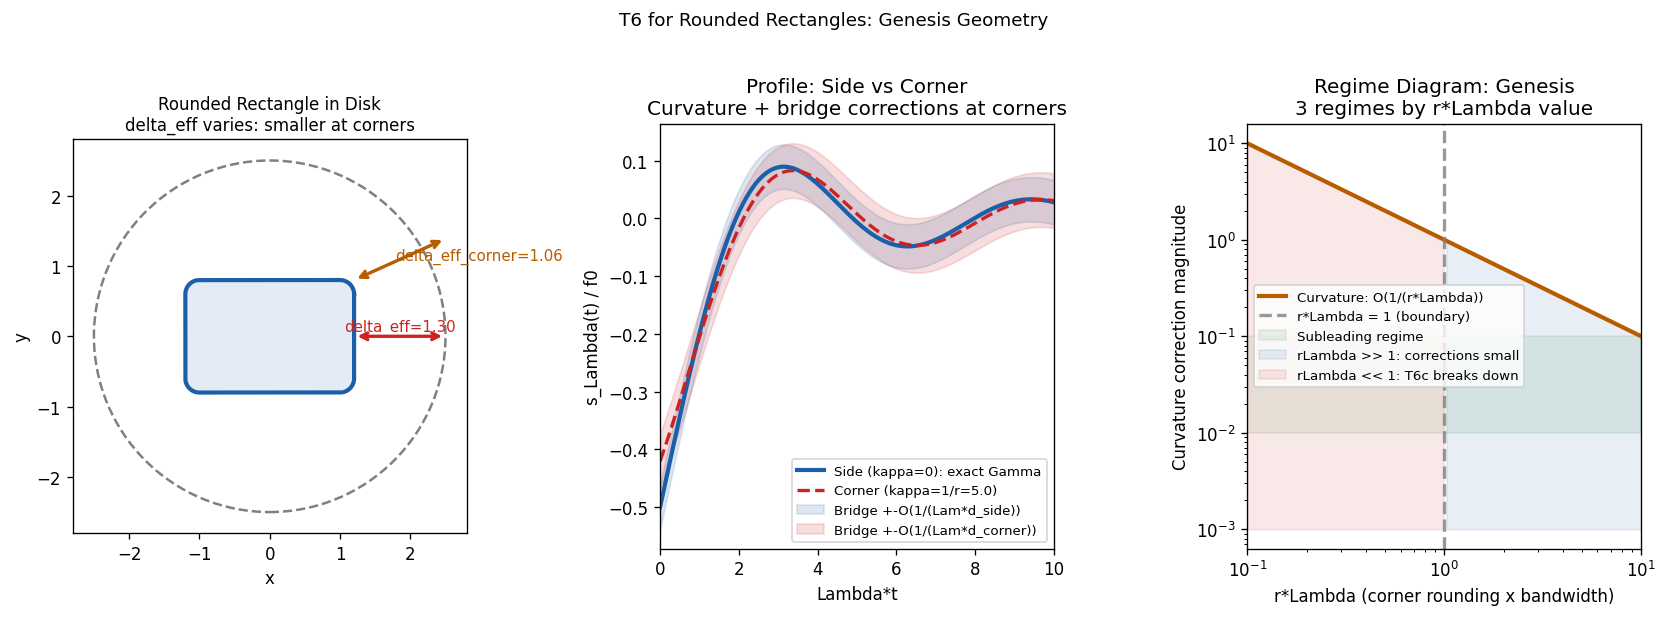

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici

plt.rcParams.update({'figure.dpi':120,'font.size':10})
BLUE='#1a5fa8'; AMBER='#b85c00'; GREEN='#2a8c3a'; RED='#cc2222'

def Gamma_fn(u):
    u = np.maximum(np.asarray(u, float), 1e-12)
    Si_u, _ = sici(u)
    return 0.5 - Si_u/np.pi

# Rounded rectangle geometry
a, b, r = 1.2, 0.8, 0.2   # half-width, half-height, corner radius
R_disk = 2.5               # disk radius

# delta_eff at sides and corners
d_side_long = R_disk - a
d_side_short = R_disk - b
d_corner = R_disk - np.sqrt(a**2 + b**2)
print(f'delta_eff: long side = {d_side_long:.3f}, short side = {d_side_short:.3f}, corner = {d_corner:.3f}')
print(f'Corner enhancement factor (vs long side) = {d_side_long/d_corner:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1: Rounded rectangle boundary with delta_eff annotation
theta = np.linspace(0, 2*np.pi, 1000)
# Draw rounded rectangle
def rounded_rect(theta, a, b, r):
    cx = np.array([a-r, -(a-r), -(a-r), a-r])
    cy = np.array([b-r, b-r, -(b-r), -(b-r)])
    x, y = np.zeros_like(theta), np.zeros_like(theta)
    for i, t in enumerate(theta):
        t_mod = t % (2*np.pi)
        if t_mod < np.pi/2: x[i], y[i] = cx[0]+r*np.cos(t_mod), cy[0]+r*np.sin(t_mod)
        elif t_mod < np.pi: x[i], y[i] = cx[1]+r*np.cos(t_mod), cy[1]+r*np.sin(t_mod)
        elif t_mod < 3*np.pi/2: x[i], y[i] = cx[2]+r*np.cos(t_mod), cy[2]+r*np.sin(t_mod)
        else: x[i], y[i] = cx[3]+r*np.cos(t_mod), cy[3]+r*np.sin(t_mod)
    return x, y

rx, ry = rounded_rect(theta, a, b, r)
ax = axes[0]
circle = plt.Circle((0,0), R_disk, fill=False, color='gray', lw=1.5, ls='--')
ax.add_patch(circle)
ax.plot(rx, ry, color=BLUE, lw=2.5)
ax.fill(rx, ry, alpha=0.12, color=BLUE)
# Mark delta_eff at characteristic points
ax.annotate('', xy=(R_disk, 0), xytext=(a, 0),
           arrowprops=dict(arrowstyle='<->', color=RED, lw=2))
ax.text((R_disk+a)/2, 0.08, f'delta_eff={d_side_long:.2f}', color=RED, ha='center', fontsize=9)
ax.annotate('', xy=(np.sqrt(a**2+b**2)/np.sqrt(a**2+b**2)*R_disk, R_disk*b/np.sqrt(a**2+b**2)),
           xytext=(a, b),
           arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text((R_disk*a/np.sqrt(a**2+b**2)+a)/2+0.15, (R_disk*b/np.sqrt(a**2+b**2)+b)/2,
       f'delta_eff_corner={d_corner:.2f}', color=AMBER, fontsize=9)
ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
ax.set_aspect('equal'); ax.set_title('Rounded Rectangle in Disk\ndelta_eff varies: smaller at corners', fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y')

# 2: Profile comparison -- side vs corner
t_arr = np.linspace(0, 0.6, 400)
Lam2 = 20; f0 = 1.0; kappa_corner = 1/r

s_side = -f0 * Gamma_fn(Lam2 * t_arr)   # kappa=0: exact Gamma
s_corner = -f0 * Gamma_fn(Lam2 * t_arr) + (f0*kappa_corner/Lam2)*(np.cos(Lam2*t_arr)/np.pi - Lam2*t_arr*Gamma_fn(Lam2*t_arr))
bridge_side = 1/(Lam2 * d_side_long) * np.ones_like(t_arr)
bridge_corner = 1/(Lam2 * d_corner) * np.ones_like(t_arr)

axes[1].plot(t_arr*Lam2, s_side, color=BLUE, lw=2.5, label='Side (kappa=0): exact Gamma')
axes[1].plot(t_arr*Lam2, s_corner, color=RED, lw=2, ls='--', label=f'Corner (kappa=1/r={1/r:.1f})')
axes[1].fill_between(t_arr*Lam2, s_side-bridge_side, s_side+bridge_side,
                    alpha=0.15, color=BLUE, label=f'Bridge +-O(1/(Lam*d_side))')
axes[1].fill_between(t_arr*Lam2, s_corner-bridge_corner, s_corner+bridge_corner,
                    alpha=0.15, color=RED, label=f'Bridge +-O(1/(Lam*d_corner))')
axes[1].set_xlabel('Lambda*t')
axes[1].set_ylabel('s_Lambda(t) / f0')
axes[1].set_title('Profile: Side vs Corner\nCurvature + bridge corrections at corners')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 10)

# 3: rLambda regime diagram
rLam = np.linspace(0.1, 10, 300)
# Correction magnitude O(1/(rLambda))
curv_corr = 1/rLam
axes[2].loglog(rLam, curv_corr, color=AMBER, lw=2.5, label='Curvature: O(1/(r*Lambda))')
axes[2].axvline(1, color='gray', lw=2, ls='--', alpha=0.8, label='r*Lambda = 1 (boundary)')
axes[2].axhspan(0.01, 0.1, alpha=0.1, color=GREEN, label='Subleading regime')
axes[2].fill_between(rLam[rLam>=1], 0.001, curv_corr[rLam>=1], alpha=0.1, color=BLUE, label='rLambda >> 1: corrections small')
axes[2].fill_between(rLam[rLam<1], 0.001, curv_corr[rLam<1], alpha=0.1, color=RED, label='rLambda << 1: T6c breaks down')
axes[2].set_xlabel('r*Lambda (corner rounding x bandwidth)')
axes[2].set_ylabel('Curvature correction magnitude')
axes[2].set_title('Regime Diagram: Genesis\n3 regimes by r*Lambda value')
axes[2].legend(fontsize=8)
axes[2].set_xlim(0.1, 10)

plt.suptitle('T6 for Rounded Rectangles: Genesis Geometry', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
